# Lab 2: Student Survey Data Preprocessing and Simple Linear Regression

## AIM
To collect real-world student survey data using Google Forms, preprocess and clean the dataset, perform Simple Linear Regression using Scikit-learn, compare regression experiments, and identify suitable dependent and independent variables.


## Part A: Data Collection and Preprocessing

Tasks covered:
1. Load the dataset using Pandas
2. Display the first 5 rows
3. Check dataset dimensions
4. Identify missing values
5. Remove or handle null values
6. Convert required columns into numerical datatype
7. Remove duplicate records if present
8. Generate statistical summary
9. Select appropriate dependent and independent variables


In [1]:
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


### 1. Load the Dataset Using Pandas


In [2]:
df = pd.read_csv("../datasets/Dept_Awareness_Survey.csv")


### 2. Display the First 5 Rows


In [3]:
display(df.head())


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


### 3. Check Dataset Dimensions


In [4]:
print("Rows and columns:", df.shape)


Rows and columns: (54, 15)


### Clean Column Names

The original Google Form column names contain extra spaces and newline characters, so short column names are created for easier analysis.


In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

df = df.rename(columns={
    "Registration Number": "registration_number",
    "Email": "email",
    "Job role that you are interested in": "job_role",
    "What is the minimum salary of students placed through campus (In LPA..respond as a number)": "min_salary_lpa",
    "What is the maximum salary of students placed through campus (In LPA..respond as a number)": "max_salary_lpa",
    "What is the median salary of students placed through campus (In LPA..respond as a number)": "median_salary_lpa",
    "Which is the highest paying company": "highest_paying_company",
    "Rate your contribution towards extra curricular activities": "extra_curricular_rating",
    "Rate your technical competencies": "technical_rating",
    "What are your package expectations (LPA)": "expected_package_lpa",
    "your CIA % of last semester": "cia_percent",
    "your GPA of last semester": "gpa",
    "Your maximum attendance % till last semester": "attendance_percent",
    "Internships Interests": "internship_interest",
})

display(df.head())


,Timestamp,registration_number,email,job_role,min_salary_lpa,max_salary_lpa,median_salary_lpa,highest_paying_company,extra_curricular_rating,technical_rating,expected_package_lpa,cia_percent,gpa,attendance_percent,internship_interest
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


### 4. Identify Missing Values

Some missing values are stored as text such as `Option 1`, `-`, or `na`, so they must be converted to actual null values before counting missing data.


In [6]:
missing_like_values = ["", " ", "-", "na", "n/a", "none", "null", "option 1"]

def replace_missing_like(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.lower() in missing_like_values:
        return np.nan
    return text

clean_df = df.copy()
clean_df = clean_df.map(replace_missing_like)

display(clean_df.isna().sum())


Timestamp                  0
registration_number        0
email                      0
job_role                   0
min_salary_lpa             0
max_salary_lpa             9
median_salary_lpa          0
highest_paying_company     0
extra_curricular_rating    0
technical_rating           0
expected_package_lpa       0
cia_percent                1
gpa                        1
attendance_percent         6
internship_interest        0
dtype: int64

### 5. Remove or Handle Null Values

For this lab, invalid or missing values are converted to `NaN`. Rows required for regression are removed only after the numerical columns are cleaned.


In [7]:
def validate_registration_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    return text if re.fullmatch(r"\d{7}", text) else np.nan

clean_df["registration_number"] = clean_df["registration_number"].apply(validate_registration_number)

print("Missing values after converting invalid registration numbers:")
display(clean_df.isna().sum())

print("Rows with invalid registration numbers:")
display(clean_df[clean_df["registration_number"].isna()][["registration_number", "email", "job_role"]])


Missing values after converting invalid registration numbers:


Timestamp                  0
registration_number        2
email                      0
job_role                   0
min_salary_lpa             0
max_salary_lpa             9
median_salary_lpa          0
highest_paying_company     0
extra_curricular_rating    0
technical_rating           0
expected_package_lpa       0
cia_percent                1
gpa                        1
attendance_percent         6
internship_interest        0
dtype: int64

Rows with invalid registration numbers:


,registration_number,email,job_role
25,NaN,nayana.benny@mca.christuniversity.in,Software Engineer
36,NaN,nilesh.gupta@mca.christuniversity.in,Data Scientist


### 6. Convert Required Columns Into Numerical Datatype

Salary and package values are standardized to LPA. Percentages are converted to numbers by removing `%` signs. GPA values outside the valid 0-4 range are treated as invalid.


In [8]:
def salary_to_lpa(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().replace(",", "").strip()
    text = re.sub(r"\s+", "", text)

    if "cr" in text:
        numbers = re.findall(r"\d+\.?\d*", text)
        return float(numbers[0]) * 100 if numbers else np.nan

    numbers = re.findall(r"\d+\.?\d*", text)

    if len(numbers) >= 2:
        return (float(numbers[0]) + float(numbers[1])) / 2

    if len(numbers) == 1:
        amount = float(numbers[0])
        if amount >= 100000:
            return amount / 100000
        return amount

    return np.nan


def percent_to_float(value):
    if pd.isna(value):
        return np.nan

    text = str(value).replace("%", "").strip()
    return pd.to_numeric(text, errors="coerce")

salary_columns = [
    "min_salary_lpa",
    "max_salary_lpa",
    "median_salary_lpa",
    "expected_package_lpa",
]

for column in salary_columns:
    clean_df[column] = clean_df[column].apply(salary_to_lpa)

percentage_columns = ["cia_percent", "attendance_percent"]
for column in percentage_columns:
    clean_df[column] = clean_df[column].apply(percent_to_float)

numeric_columns = [
    "extra_curricular_rating",
    "technical_rating",
    "gpa",
]

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

clean_df.loc[~clean_df["gpa"].between(0, 4), "gpa"] = np.nan

# CIA and attendance are percentages. Very low values such as 4 are treated as data-entry errors
# because this survey is about last-semester academic percentage values.
clean_df.loc[~clean_df["cia_percent"].between(40, 100), "cia_percent"] = np.nan
clean_df.loc[~clean_df["attendance_percent"].between(40, 100), "attendance_percent"] = np.nan
clean_df.loc[~clean_df["extra_curricular_rating"].between(1, 5), "extra_curricular_rating"] = np.nan
clean_df.loc[~clean_df["technical_rating"].between(1, 5), "technical_rating"] = np.nan

print("Datatypes after conversion:")
display(clean_df.dtypes)

display(clean_df.head())


Datatypes after conversion:


Timestamp                      str
registration_number            str
email                          str
job_role                       str
min_salary_lpa             float64
max_salary_lpa             float64
median_salary_lpa          float64
highest_paying_company         str
extra_curricular_rating    float64
technical_rating           float64
expected_package_lpa       float64
cia_percent                float64
gpa                        float64
attendance_percent         float64
internship_interest            str
dtype: object

,Timestamp,registration_number,email,job_role,min_salary_lpa,max_salary_lpa,median_salary_lpa,highest_paying_company,extra_curricular_rating,technical_rating,expected_package_lpa,cia_percent,gpa,attendance_percent,internship_interest
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4.0,NaN,9.0,Deolite,2.0,2.0,7.0,78.00,3.24,NaN,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,7.0,NaN,4.5,Deolite,4.0,3.0,6.0,64.78,3.20,NaN,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6.0,17.0,8.0,DE Shaw,5.0,5.0,13.0,80.00,3.60,NaN,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12.0,6.9,DE Shaw,3.0,4.0,7.0,70.00,3.20,92.0,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8.0,12.0,10.0,EY,5.0,3.0,10.0,68.00,3.40,85.0,Industry


**Validation note:** CIA percentage and attendance percentage are academic percentage values, so entries below 40 are treated as invalid survey responses. This handles cases like `CIA = 4`, which would otherwise distort the CIA vs GPA regression line.


### 7. Remove Duplicate Records if Present


In [9]:
print("Duplicate rows:", clean_df.duplicated().sum())
print("Duplicate email records:", clean_df.duplicated(subset=["email"]).sum())

clean_df = clean_df.drop_duplicates(subset=["email"], keep="last").reset_index(drop=True)

print("Shape after duplicate removal:", clean_df.shape)


Duplicate rows: 0
Duplicate email records: 2
Shape after duplicate removal: (52, 15)


### Final Missing Value Check


In [10]:
display(clean_df.isna().sum())


Timestamp                  0
registration_number        2
email                      0
job_role                   0
min_salary_lpa             0
max_salary_lpa             7
median_salary_lpa          0
highest_paying_company     0
extra_curricular_rating    0
technical_rating           0
expected_package_lpa       0
cia_percent                3
gpa                        4
attendance_percent         4
internship_interest        0
dtype: int64

### 8. Generate Statistical Summary


In [11]:
display(clean_df.describe())


,min_salary_lpa,max_salary_lpa,median_salary_lpa,extra_curricular_rating,technical_rating,expected_package_lpa,cia_percent,gpa,attendance_percent
count,52.000000,45.000000,52.000000,52.000000,52.000000,52.000000,49.000000,48.000000,48.000000
mean,389.609615,1793.577778,8.150000,3.615385,3.442308,13.894231,74.161837,3.487500,93.121458
std,2772.795909,11923.294722,5.813254,0.973247,0.826366,27.364521,6.553178,0.269369,4.807110
min,2.000000,8.000000,4.500000,2.000000,1.000000,5.000000,60.000000,2.900000,85.000000
25%,4.000000,12.000000,6.000000,3.000000,3.000000,7.000000,70.000000,3.392500,89.000000
50%,4.500000,12.000000,7.000000,4.000000,3.000000,8.750000,71.110000,3.500000,93.500000
75%,6.000000,15.000000,8.000000,4.000000,4.000000,12.000000,80.000000,3.647500,97.992500
max,20000.000000,80000.000000,45.000000,5.000000,5.000000,200.000000,89.000000,4.000000,100.000000


### Visual Representation of Cleaned Data

The following charts help explain the cleaned dataset before applying regression. They show missing values, numerical distributions, categorical counts, and the relationship among numerical variables.


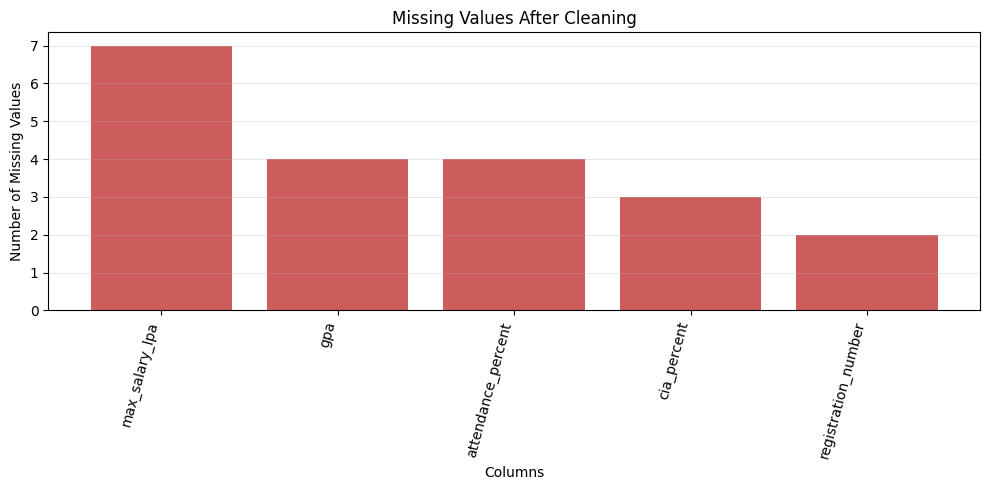

In [12]:
plt.figure(figsize=(10, 5))
missing_counts = clean_df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

plt.bar(missing_counts.index, missing_counts.values, color="indianred")
plt.title("Missing Values After Cleaning")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


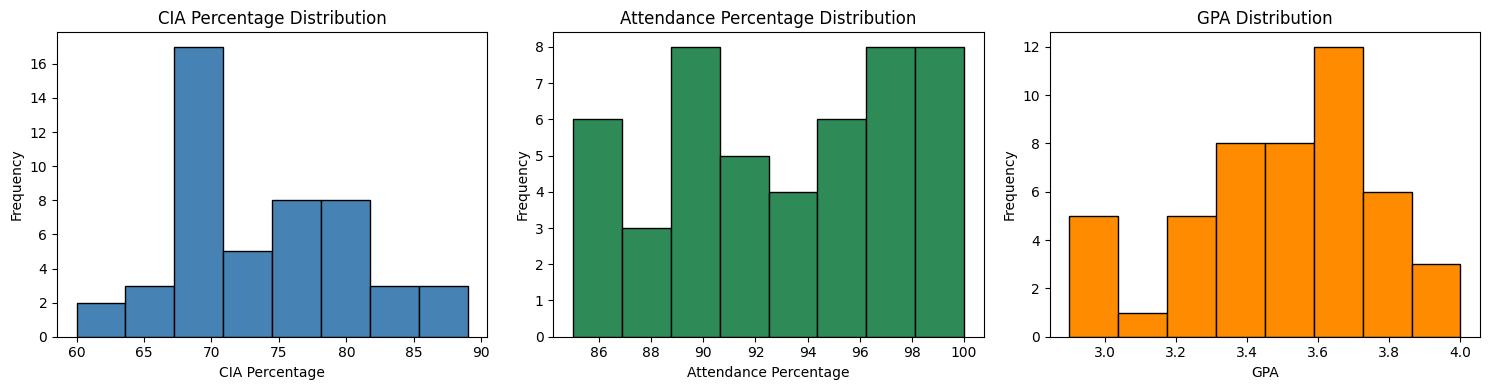

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(clean_df["cia_percent"].dropna(), bins=8, color="steelblue", edgecolor="black")
axes[0].set_title("CIA Percentage Distribution")
axes[0].set_xlabel("CIA Percentage")
axes[0].set_ylabel("Frequency")

axes[1].hist(clean_df["attendance_percent"].dropna(), bins=8, color="seagreen", edgecolor="black")
axes[1].set_title("Attendance Percentage Distribution")
axes[1].set_xlabel("Attendance Percentage")
axes[1].set_ylabel("Frequency")

axes[2].hist(clean_df["gpa"].dropna(), bins=8, color="darkorange", edgecolor="black")
axes[2].set_title("GPA Distribution")
axes[2].set_xlabel("GPA")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


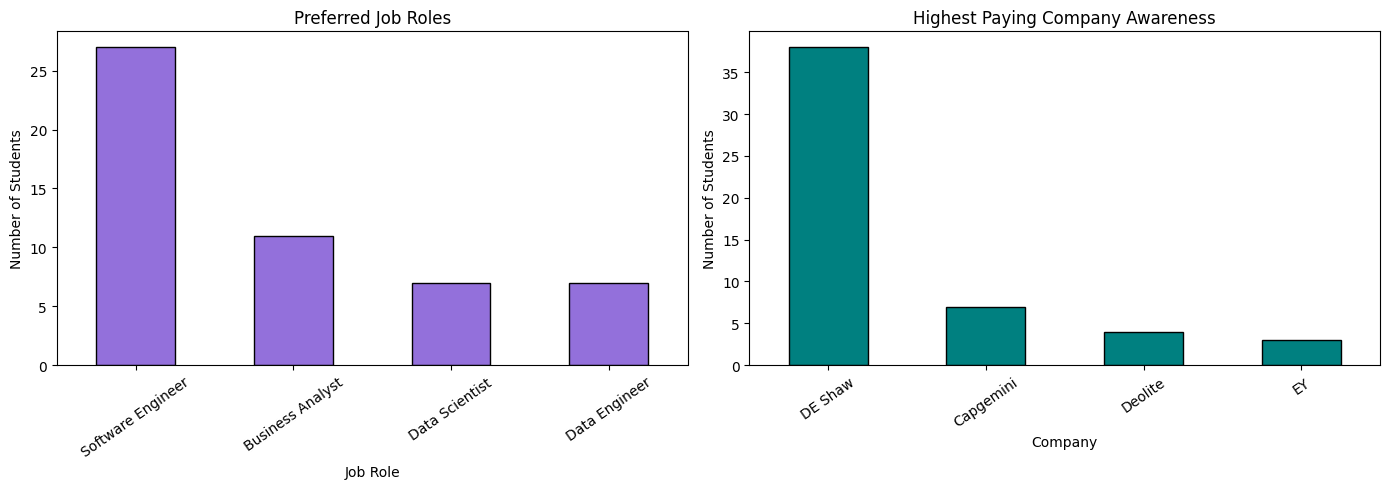

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_df["job_role"].value_counts().plot(kind="bar", ax=axes[0], color="mediumpurple", edgecolor="black")
axes[0].set_title("Preferred Job Roles")
axes[0].set_xlabel("Job Role")
axes[0].set_ylabel("Number of Students")
axes[0].tick_params(axis="x", rotation=35)

clean_df["highest_paying_company"].value_counts().plot(kind="bar", ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("Highest Paying Company Awareness")
axes[1].set_xlabel("Company")
axes[1].set_ylabel("Number of Students")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


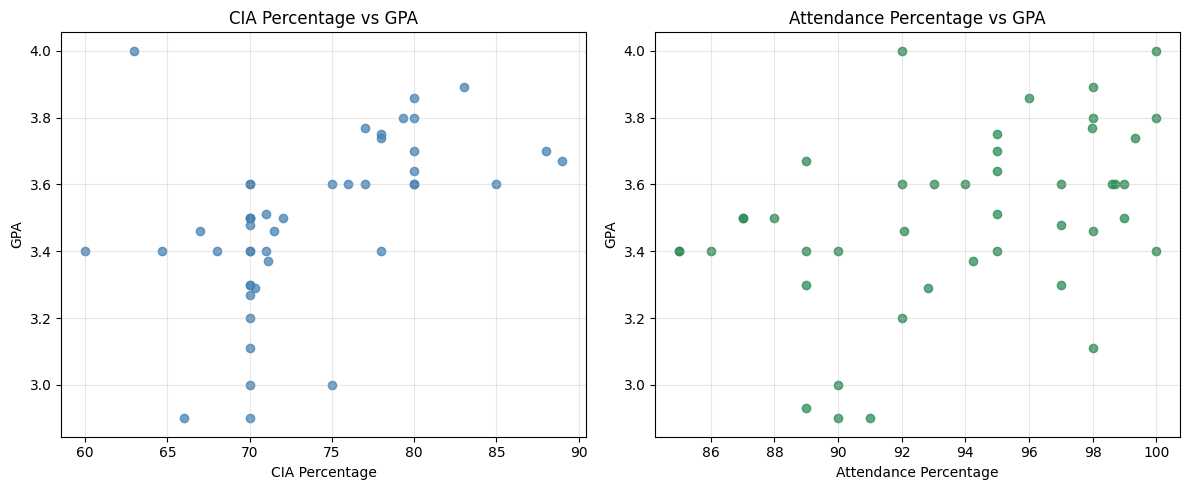

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(clean_df["cia_percent"], clean_df["gpa"], color="steelblue", alpha=0.75)
axes[0].set_title("CIA Percentage vs GPA")
axes[0].set_xlabel("CIA Percentage")
axes[0].set_ylabel("GPA")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(clean_df["attendance_percent"], clean_df["gpa"], color="seagreen", alpha=0.75)
axes[1].set_title("Attendance Percentage vs GPA")
axes[1].set_xlabel("Attendance Percentage")
axes[1].set_ylabel("GPA")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


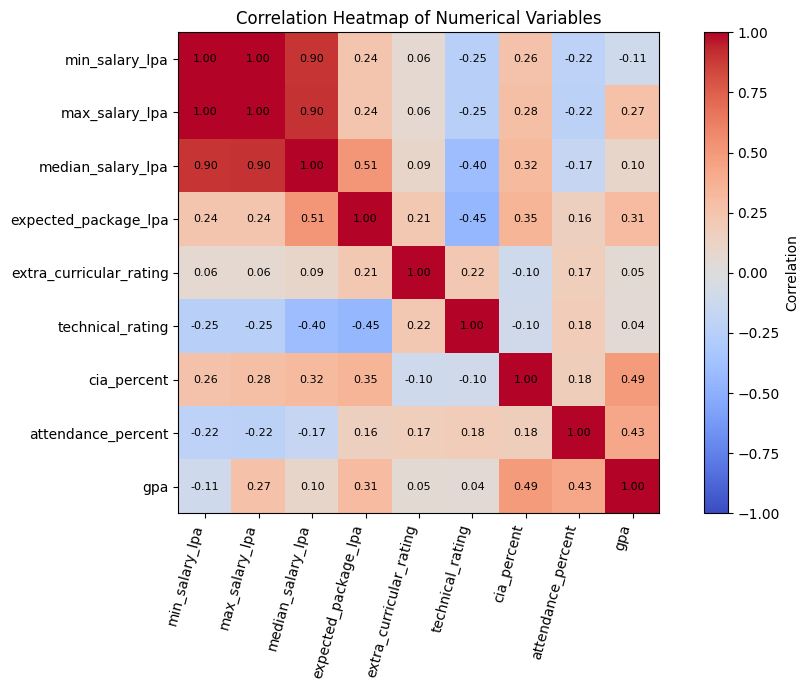

In [16]:
numeric_for_corr = clean_df[[
    "min_salary_lpa",
    "max_salary_lpa",
    "median_salary_lpa",
    "expected_package_lpa",
    "extra_curricular_rating",
    "technical_rating",
    "cia_percent",
    "attendance_percent",
    "gpa",
]]

corr = numeric_for_corr.corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numerical Variables")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### 9. Select Appropriate Dependent and Independent Variables

Regression Experiment 1:
- Independent variable: `cia_percent`
- Dependent variable: `gpa`

Regression Experiment 2:
- Independent variable: `attendance_percent`
- Dependent variable: `gpa`


In [17]:
regression_df = clean_df.dropna(subset=["gpa"]).copy()

# Median imputation is used for missing independent variables after invalid values are removed.
# GPA is the dependent variable, so rows with missing GPA are not imputed.
for column in ["cia_percent", "attendance_percent"]:
    regression_df[column] = regression_df[column].fillna(regression_df[column].median())

experiment_1 = regression_df[["cia_percent", "gpa"]]
experiment_2 = regression_df[["attendance_percent", "gpa"]]

print("Regression dataset shape after handling missing values:", regression_df.shape)
print("Experiment 1 dataset shape:", experiment_1.shape)
print("Experiment 2 dataset shape:", experiment_2.shape)

display(experiment_1.head())
display(experiment_2.head())


Regression dataset shape after handling missing values: (48, 15)
Experiment 1 dataset shape: (48, 2)
Experiment 2 dataset shape: (48, 2)


,cia_percent,gpa
0,80.0,3.6
1,70.0,3.2
2,68.0,3.4
3,70.0,3.5
4,88.0,3.7


,attendance_percent,gpa
0,94.625,3.6
1,92.000,3.2
2,85.000,3.4
3,87.000,3.5
4,94.625,3.7


## Part B: Simple Linear Regression Using Scikit-learn

The same function is used for both experiments:
1. Split the dataset into training and testing sets
2. Train `LinearRegression`
3. Obtain slope and intercept
4. Predict output values using the trained model
5. Evaluate the model


In [18]:
def run_simple_linear_regression(data, independent_variable, dependent_variable, experiment_name):
    X = data[[independent_variable]]
    y = data[dependent_variable]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    slope = model.coef_[0]
    intercept = model.intercept_

    print(experiment_name)
    print("Slope:", slope)
    print("Intercept:", intercept)
    print("Regression equation: GPA =", round(intercept, 4), "+", round(slope, 4), "*", independent_variable)
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

    results = pd.DataFrame({
        independent_variable: X_test[independent_variable].values,
        "Actual GPA": y_test.values,
        "Predicted GPA": y_pred,
    })

    display(results)

    plt.figure(figsize=(7, 5))
    plt.scatter(X, y, color="steelblue", label="Actual values")
    plt.plot(X, model.predict(X), color="crimson", label="Regression line")
    plt.xlabel(independent_variable)
    plt.ylabel(dependent_variable)
    plt.title(experiment_name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    train_data = X_train.copy()
    train_data[dependent_variable] = y_train.values

    test_data = X_test.copy()
    test_data[dependent_variable] = y_test.values

    return model, results, train_data, test_data


### Experiment 1: CIA Percentage vs GPA


Experiment 1: CIA Percentage vs GPA
Slope: 0.017744727868088336
Intercept: 2.1659817069523912
Regression equation: GPA = 2.166 + 0.0177 * cia_percent
Mean Absolute Error: 0.1087995542906508
Mean Squared Error: 0.020310328086975204
R2 Score: -0.08264008992405159


,cia_percent,Actual GPA,Predicted GPA
0,75.0,3.60,3.496836
1,77.0,3.77,3.532326
2,80.0,3.86,3.585560
3,71.5,3.46,3.434730
4,70.0,3.40,3.408113
5,80.0,3.80,3.585560
6,89.0,3.67,3.745262
7,80.0,3.64,3.585560
8,88.0,3.70,3.727518
9,77.0,3.60,3.532326


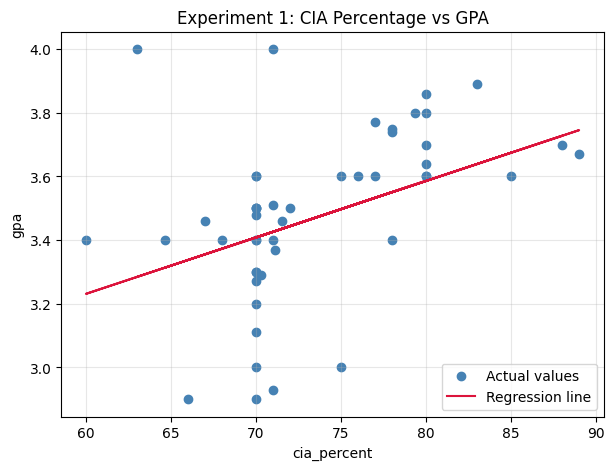

In [19]:
model_cia, results_cia, train_cia, test_cia = run_simple_linear_regression(
    data=experiment_1,
    independent_variable="cia_percent",
    dependent_variable="gpa",
    experiment_name="Experiment 1: CIA Percentage vs GPA",
)


### Experiment 2: Attendance Percentage vs GPA


Experiment 2: Attendance Percentage vs GPA
Slope: 0.024904388795246406
Intercept: 1.1130863794031556
Regression equation: GPA = 1.1131 + 0.0249 * attendance_percent
Mean Absolute Error: 0.20315099468213674
Mean Squared Error: 0.04932574211482196
R2 Score: -1.629303950683474


,attendance_percent,Actual GPA,Predicted GPA
0,94.000,3.60,3.454099
1,97.990,3.77,3.553467
2,96.000,3.86,3.503908
3,98.000,3.46,3.553716
4,85.000,3.40,3.229959
5,98.000,3.80,3.553716
6,89.000,3.67,3.329577
7,95.000,3.64,3.479003
8,94.625,3.70,3.469664
9,97.000,3.60,3.528812


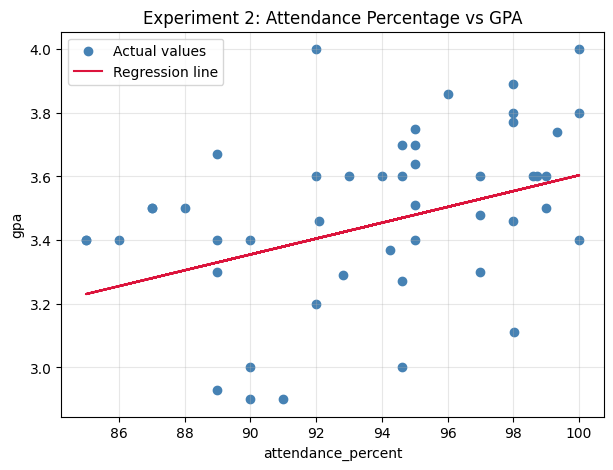

In [20]:
model_attendance, results_attendance, train_attendance, test_attendance = run_simple_linear_regression(
    data=experiment_2,
    independent_variable="attendance_percent",
    dependent_variable="gpa",
    experiment_name="Experiment 2: Attendance Percentage vs GPA",
)


## Part C: Manual Computation Using Ordinary Least Squares (OLS)

For simple linear regression, the regression equation is:

\[
Y = mX + c
\]

where:
- `m` is the slope
- `c` is the intercept

The OLS formulas are:

\[
m = rac{\sum (x_i - ar{x})(y_i - ar{y})}{\sum (x_i - ar{x})^2}
\]

\[
c = ar{y} - mar{x}
\]


In [21]:
def compute_ols_parameters(data, independent_variable, dependent_variable):
    x = data[independent_variable].to_numpy(dtype=float)
    y = data[dependent_variable].to_numpy(dtype=float)

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)

    slope = numerator / denominator
    intercept = y_mean - (slope * x_mean)

    return slope, intercept


def predict_using_ols(x_values, slope, intercept):
    return intercept + slope * x_values


### Manual OLS: Experiment 1 CIA Percentage vs GPA


In [22]:
ols_cia_slope, ols_cia_intercept = compute_ols_parameters(
    train_cia,
    independent_variable="cia_percent",
    dependent_variable="gpa",
)

print("Manual OLS slope:", ols_cia_slope)
print("Manual OLS intercept:", ols_cia_intercept)
print("Manual regression equation: GPA =", round(ols_cia_intercept, 4), "+", round(ols_cia_slope, 4), "* cia_percent")


Manual OLS slope: 0.017744727868088322
Manual OLS intercept: 2.165981706952392
Manual regression equation: GPA = 2.166 + 0.0177 * cia_percent


### Manual OLS: Experiment 2 Attendance Percentage vs GPA


In [23]:
ols_attendance_slope, ols_attendance_intercept = compute_ols_parameters(
    train_attendance,
    independent_variable="attendance_percent",
    dependent_variable="gpa",
)

print("Manual OLS slope:", ols_attendance_slope)
print("Manual OLS intercept:", ols_attendance_intercept)
print("Manual regression equation: GPA =", round(ols_attendance_intercept, 4), "+", round(ols_attendance_slope, 4), "* attendance_percent")


Manual OLS slope: 0.024904388795246424
Manual OLS intercept: 1.1130863794031542
Manual regression equation: GPA = 1.1131 + 0.0249 * attendance_percent


## Comparison of Scikit-learn and Manual OLS Predictions

Both methods are trained using the same training split and compared on the same testing split. The predictions should be almost identical because Scikit-learn's `LinearRegression` also estimates slope and intercept using the least-squares approach.


In [24]:
def compare_sklearn_and_ols(data, independent_variable, dependent_variable, sklearn_model, ols_slope, ols_intercept):
    comparison = data[[independent_variable, dependent_variable]].copy()
    comparison["sklearn_prediction"] = sklearn_model.predict(comparison[[independent_variable]])
    comparison["manual_ols_prediction"] = predict_using_ols(
        comparison[independent_variable].to_numpy(dtype=float),
        ols_slope,
        ols_intercept,
    )
    comparison["difference"] = comparison["sklearn_prediction"] - comparison["manual_ols_prediction"]
    return comparison

comparison_cia = compare_sklearn_and_ols(
    test_cia,
    independent_variable="cia_percent",
    dependent_variable="gpa",
    sklearn_model=model_cia,
    ols_slope=ols_cia_slope,
    ols_intercept=ols_cia_intercept,
)

comparison_attendance = compare_sklearn_and_ols(
    test_attendance,
    independent_variable="attendance_percent",
    dependent_variable="gpa",
    sklearn_model=model_attendance,
    ols_slope=ols_attendance_slope,
    ols_intercept=ols_attendance_intercept,
)

print("CIA model maximum absolute prediction difference:", comparison_cia["difference"].abs().max())
print("Attendance model maximum absolute prediction difference:", comparison_attendance["difference"].abs().max())

display(comparison_cia.head())
display(comparison_attendance.head())


CIA model maximum absolute prediction difference: 8.881784197001252e-16
Attendance model maximum absolute prediction difference: 4.440892098500626e-16


,cia_percent,gpa,sklearn_prediction,manual_ols_prediction,difference
30,75.0,3.60,3.496836,3.496836,0.000000e+00
43,77.0,3.77,3.532326,3.532326,4.440892e-16
29,80.0,3.86,3.585560,3.585560,4.440892e-16
46,71.5,3.46,3.434730,3.434730,0.000000e+00
26,70.0,3.40,3.408113,3.408113,0.000000e+00


,attendance_percent,gpa,sklearn_prediction,manual_ols_prediction,difference
30,94.00,3.60,3.454099,3.454099,0.000000e+00
43,97.99,3.77,3.553467,3.553467,-4.440892e-16
29,96.00,3.86,3.503908,3.503908,-4.440892e-16
46,98.00,3.46,3.553716,3.553716,-4.440892e-16
26,85.00,3.40,3.229959,3.229959,0.000000e+00


## Parameter Saving Task Using Pickle

The learned slope and intercept values are saved in a Pickle file, loaded again, and used for prediction.


In [25]:
model_parameters = {
    "experiment_1_cia_vs_gpa": {
        "slope": model_cia.coef_[0],
        "intercept": model_cia.intercept_,
    },
    "experiment_2_attendance_vs_gpa": {
        "slope": model_attendance.coef_[0],
        "intercept": model_attendance.intercept_,
    },
}

pickle_file = Path("../linear_regression_weights.pkl")

with open(pickle_file, "wb") as file:
    pickle.dump(model_parameters, file)

print("Parameters saved to:", pickle_file)
print(model_parameters)


Parameters saved to: ../linear_regression_weights.pkl
{'experiment_1_cia_vs_gpa': {'slope': np.float64(0.017744727868088336), 'intercept': np.float64(2.1659817069523912)}, 'experiment_2_attendance_vs_gpa': {'slope': np.float64(0.024904388795246406), 'intercept': np.float64(1.1130863794031556)}}


In [26]:
with open(pickle_file, "rb") as file:
    loaded_parameters = pickle.load(file)

sample_cia = 80
sample_attendance = 95

cia_prediction = (
    loaded_parameters["experiment_1_cia_vs_gpa"]["intercept"]
    + loaded_parameters["experiment_1_cia_vs_gpa"]["slope"] * sample_cia
)

attendance_prediction = (
    loaded_parameters["experiment_2_attendance_vs_gpa"]["intercept"]
    + loaded_parameters["experiment_2_attendance_vs_gpa"]["slope"] * sample_attendance
)

print("Loaded parameters:")
print(loaded_parameters)
print("Predicted GPA for CIA percentage 80:", cia_prediction)
print("Predicted GPA for attendance percentage 95:", attendance_prediction)


Loaded parameters:
{'experiment_1_cia_vs_gpa': {'slope': np.float64(0.017744727868088336), 'intercept': np.float64(2.1659817069523912)}, 'experiment_2_attendance_vs_gpa': {'slope': np.float64(0.024904388795246406), 'intercept': np.float64(1.1130863794031556)}}
Predicted GPA for CIA percentage 80: 3.5855599363994584
Predicted GPA for attendance percentage 95: 3.479003314951564


## Observations and Inference

- The dataset contained non-standard values such as `Option 1`, percentage signs, and invalid academic values, so preprocessing was necessary before model training.
- Invalid CIA values below 40 were treated as data-entry errors because CIA is expected to be an academic percentage.
- Missing independent variable values were handled using median imputation, while missing GPA values were removed because GPA is the target variable.
- Scikit-learn and manual OLS produce nearly identical regression parameters and predictions.
- CIA percentage is expected to have a meaningful relationship with GPA because CIA contributes directly to academic performance evaluation.
- Attendance percentage may show some relationship with GPA, but it is not necessarily a direct cause of GPA change.


## Conclusion

The complete lab requirements were performed. The survey dataset was cleaned, visualized, and used for two Simple Linear Regression experiments. Regression was implemented using Scikit-learn and manually using OLS formulas. The predictions from both methods were compared, and the learned slope and intercept parameters were saved and loaded using Pickle.
